In [11]:
import pandas as pd
import numpy as np

# Cargar datasets
train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")

# Inspección rápida
print(train_df.head())
print(train_df['Category'].value_counts())

      Topic          Source  \
0  Sociedad    Mvs Noticias   
1    Crimen    Caso Aislado   
2  Covid-19  Tamaulipas Gob   
3  Sociedad  Nuevodiarioweb   
4  Religión        Facebook   

                                            Headline  \
0  Matrimonios en México duran en promedio *NUMBE...   
1  Violentos manteros trataron de asaltar la comi...   
2  FRANCISCO CABEZA DE VACA OFRECE A FEDERACIÓN I...   
3  Mujer se hace pasar por ciega para no saludar ...   
4                                                NaN   

                                                Text  \
0  Con motivo del Día de San Valentín, que se cel...   
1  Los manteros vuelven a ser noticia por su acti...   
2  En conferencia de prensa, el gobernador Franci...   
3  Carmen Jiménez, vecina del salmantino barrio d...   
4  Ole ........POR EL ALCALDE DE HERVÁS (CÁCERES-...   

                                                Link  \
0  http://www.mvsnoticias.com/#!/noticias/matrimo...   
1  http://casoaislado.com/v

In [12]:
# Definición de datos para entrenamiento y validación

X_train_raw = train_df['Headline_Text']
X_test_raw = test_df['Headline_Text']

y_train = train_df['Category']
y_test = test_df['Category']


In [13]:
!pip install nltk

In [14]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('stopwords')
from nltk.corpus import stopwords

spanish_stopwords = stopwords.words('spanish')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lendg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Vectorización

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,              # elimina términos muy raros
    sublinear_tf=True,      # suaviza términos muy frecuentes
    stop_words=spanish_stopwords   # elimina stopwords en español
)



X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)


In [16]:
# Modelo regresión

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000,class_weight='balanced')


In [17]:
# Validación cruzada - grid search Métrica: F1 macro (balancear)
from sklearn.model_selection import StratifiedKFold, GridSearchCV



param_grid = {
    'C':[0.001, 0.01, 0.1, 0.5, 1, 5],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l2']
}

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    log_reg,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Mejores hiperparámetros:", grid.best_params_)


Mejores hiperparámetros: {'C': 5, 'penalty': 'l2', 'solver': 'saga'}


Evaluación con umbral 0.5
Matriz de confusión:
 [[516  37]
 [ 19 106]]
Exactitud (Accuracy): 0.9174041297935103

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9645    0.9331    0.9485       553
        True     0.7413    0.8480    0.7910       125

    accuracy                         0.9174       678
   macro avg     0.8529    0.8905    0.8698       678
weighted avg     0.9233    0.9174    0.9195       678

ROC-AUC: 0.9648

Umbral óptimo según F1: 0.5232517554586613

Evaluación con umbral ajustado
Matriz de confusión:
 [[521  32]
 [ 20 105]]
Exactitud (Accuracy): 0.9233038348082596

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9630    0.9421    0.9525       553
        True     0.7664    0.8400    0.8015       125

    accuracy                         0.9233       678
   macro avg     0.8647    0.8911    0.8770       678
weighted avg     0.9268    0.9233    0.9246       678



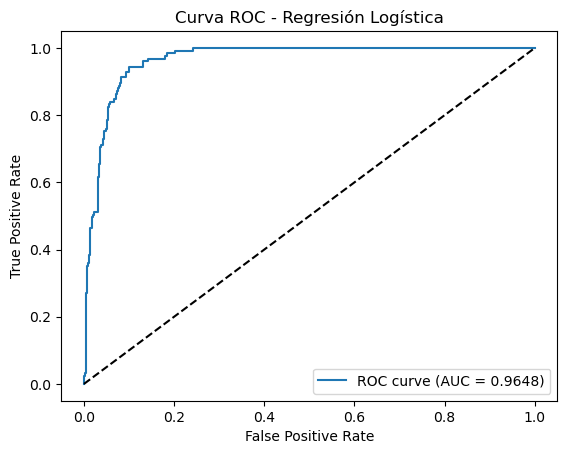

In [19]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# Evaluación con umbral estándar
y_pred = best_model.predict(X_test)

print("Evaluación con umbral 0.5")
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["False","True"], digits=4))

# Probabilidades para ROC-AUC
y_proba = best_model.predict_proba(X_test)[:,1]
roc_auc_base = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc_base:.4f}")

# Búsqueda de umbral óptimo usando curva precision-recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
print("\nUmbral óptimo según F1:", best_threshold)

# Evaluación con umbral ajustado
y_pred_custom = (y_proba >= best_threshold).astype(int)
cm_custom = confusion_matrix(y_test, y_pred_custom)
print("\nEvaluación con umbral ajustado")
print("Matriz de confusión:\n", cm_custom)
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred_custom))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_custom, target_names=["False","True"], digits=4))

# ROC-AUC para el modelo ajustado (es el mismo porque depende de las probabilidades, no del umbral)
roc_auc_adjusted = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc_adjusted:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_base:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.savefig("curva_roc_logreg.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
import joblib

# Guardar modelo y vectorizador
joblib.dump(best_model, "log_reg_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Cargar después sin reentrenar

#loaded_model = joblib.load("log_reg_model.pkl")
#loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

# Usar directamente
#X_new = loaded_tfidf.transform(["Ejemplo de texto"])
#print(loaded_model.predict(X_new))


['tfidf_vectorizer.pkl']